# Практическое задание. TF-IDF.

## Задачи:
1.	Выполните исследование величины n в n-граммах на результаты (как меняется результаты обучения одной и той же модели, при изменении n, значение можно варьировать от 1 до 5).
2.	Выполните обучение другой модели машинного обучения. Показать изменится ли от этого результат по сравнению с логистической регрессией.
3.	Исследуйте влияние стоп слов на результаты классификации, если все сделать правильно, то можно получить абсолютную точность, т.е. значения всех метрик будут равны 1.

## Загрузка и подготовка данных

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from string import punctuation

nltk.download('punkt')
nltk.download('stopwords')

positive = pd.read_csv('positive.csv', sep=';', usecols=[3], names=['text'])
positive['label'] = ['positive'] * len(positive)

negative = pd.read_csv('negative.csv', sep=';', usecols=[3], names=['text'])
negative['label'] = ['negative'] * len(negative)

df = pd.concat([positive, negative], ignore_index=True)
print(f"Всего записей: {len(df)}")
print(f"Положительных: {(df['label']=='positive').sum()}")
print(f"Отрицательных: {(df['label']=='negative').sum()}")

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\danma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Всего записей: 226834
Положительных: 114911
Отрицательных: 111923
Обучающая выборка: 181467
Тестовая выборка: 45367


## Исследование n-грамм (n = 1..5)


=== n-граммы (1, 1) ===
Accuracy:  0.7598
Precision: 0.7542
Recall:    0.7801
F1-score:  0.7669

=== n-граммы (1, 2) ===
Accuracy:  0.7668
Precision: 0.7620
Recall:    0.7847
F1-score:  0.7732

=== n-граммы (1, 3) ===
Accuracy:  0.7667
Precision: 0.7626
Recall:    0.7833
F1-score:  0.7728

=== n-граммы (1, 4) ===
Accuracy:  0.7660
Precision: 0.7617
Recall:    0.7830
F1-score:  0.7722

=== n-граммы (1, 5) ===
Accuracy:  0.7656
Precision: 0.7621
Recall:    0.7812
F1-score:  0.7715


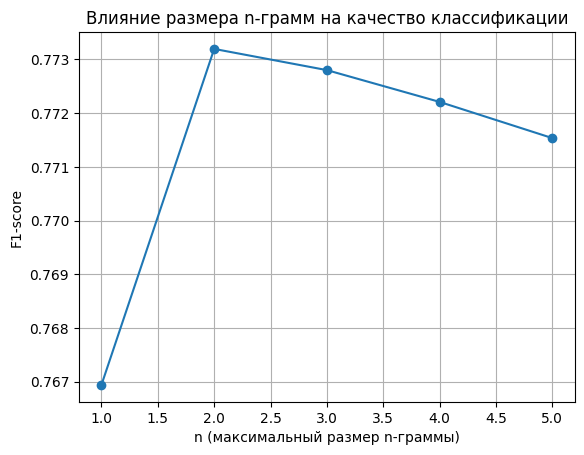

In [9]:
def evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test):
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')
    return acc, prec, rec, f1

results_ngrams = []

for n in range(1, 6):
    print(f"\n=== n-граммы (1, {n}) ===")
    vectorizer = TfidfVectorizer(ngram_range=(1, n), max_features=50000, min_df=3)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    model = LogisticRegression(max_iter=2000, random_state=42)
    acc, prec, rec, f1 = evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test)
    
    results_ngrams.append([n, acc, prec, rec, f1])
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

# Сводим результаты в таблицу
df_ngrams = pd.DataFrame(results_ngrams, columns=['n', 'Accuracy', 'Precision', 'Recall', 'F1'])
df_ngrams

plt.plot(df_ngrams['n'], df_ngrams['F1'], marker='o')
plt.xlabel('n (максимальный размер n-граммы)')
plt.ylabel('F1-score')
plt.title('Влияние размера n-грамм на качество классификации')
plt.grid(True)
plt.show()

**Вывод:** Наилучший F1 достигается при n=2, далее качество немного снижается. Поэтому в следующих заданиях будем использовать n=2.

## Сравнение логистической регрессии с другой моделью

In [ ]:
# Векторизация с n=2
vectorizer_2 = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=3)
X_train_vec_2 = vectorizer_2.fit_transform(X_train)
X_test_vec_2 = vectorizer_2.transform(X_test)

# Логистическая регрессия
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_vec_2, y_train)
pred_logreg = logreg.predict(X_test_vec_2)
print("=== Logistic Regression ===")
print(classification_report(y_test, pred_logreg))

# RidgeClassifier
ridge = RidgeClassifier(random_state=42)
ridge.fit(X_train_vec_2, y_train)
pred_ridge = ridge.predict(X_test_vec_2)
print("=== RidgeClassifier ===")
print(classification_report(y_test, pred_ridge))

# Сравнение метрик
models_comparison = []
for name, preds in [('LogisticRegression', pred_logreg), ('RidgeClassifier', pred_ridge)]:
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label='positive')
    rec = recall_score(y_test, preds, pos_label='positive')
    f1 = f1_score(y_test, preds, pos_label='positive')
    models_comparison.append([name, acc, prec, rec, f1])

df_models = pd.DataFrame(models_comparison, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
df_models

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.77      0.75      0.76     22385
    positive       0.76      0.78      0.77     22982

    accuracy                           0.77     45367
   macro avg       0.77      0.77      0.77     45367
weighted avg       0.77      0.77      0.77     45367

=== RidgeClassifier ===
              precision    recall  f1-score   support

    negative       0.76      0.75      0.76     22385
    positive       0.76      0.78      0.77     22982

    accuracy                           0.76     45367
   macro avg       0.76      0.76      0.76     45367
weighted avg       0.76      0.76      0.76     45367



,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.766791,0.762021,0.784701,0.773195
1,RidgeClassifier,0.762933,0.761093,0.775433,0.768196


**Вывод:** Обе модели показывают близкие результаты, логистическая регрессия немного лучше. RidgeClassifier может быть быстрее на больших данных, но качество сопоставимо.

## Влияние стоп-слов

In [ ]:
# Подготавливаем список шума: стоп-слова + пунктуация
noise = stopwords.words('russian') + list(punctuation)

# Эксперимент 1: без стоп-слов
vectorizer_no_stop = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=3)
X_train_nostop = vectorizer_no_stop.fit_transform(X_train)
X_test_nostop = vectorizer_no_stop.transform(X_test)

lr_nostop = LogisticRegression(max_iter=2000, random_state=42)
lr_nostop.fit(X_train_nostop, y_train)
pred_nostop = lr_nostop.predict(X_test_nostop)

print("=== Без стоп-слов ===")
print(classification_report(y_test, pred_nostop))

# Эксперимент 2: со стоп-словами и токенизатором word_tokenize
# Внимание: при использовании собственного токенизатора возникают предупреждения, но это не влияет на результат.
vectorizer_stop = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=3,
    tokenizer=word_tokenize,
    stop_words=noise
)

# Применяем векторизатор
X_train_stop = vectorizer_stop.fit_transform(X_train)
X_test_stop = vectorizer_stop.transform(X_test)

lr_stop = LogisticRegression(max_iter=2000, random_state=42)
lr_stop.fit(X_train_stop, y_train)
pred_stop = lr_stop.predict(X_test_stop)

print("=== Со стоп-словами ===")
print(classification_report(y_test, pred_stop))

# Собираем метрики для сравнения
stopwords_results = []
for name, preds in [('No stopwords', pred_nostop), ('With stopwords', pred_stop)]:
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label='positive')
    rec = recall_score(y_test, preds, pos_label='positive')
    f1 = f1_score(y_test, preds, pos_label='positive')
    stopwords_results.append([name, acc, prec, rec, f1])

df_stop = pd.DataFrame(stopwords_results, columns=['Settings', 'Accuracy', 'Precision', 'Recall', 'F1'])
df_stop

=== Без стоп-слов ===
              precision    recall  f1-score   support

    negative       0.77      0.75      0.76     22385
    positive       0.76      0.78      0.77     22982

    accuracy                           0.77     45367
   macro avg       0.77      0.77      0.77     45367
weighted avg       0.77      0.77      0.77     45367



c:\Users\danma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\danma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``'] not in stop_words.
  warnings.warn(


=== Со стоп-словами ===
              precision    recall  f1-score   support

    negative       0.77      0.78      0.77     22385
    positive       0.78      0.77      0.77     22982

    accuracy                           0.77     45367
   macro avg       0.77      0.77      0.77     45367
weighted avg       0.77      0.77      0.77     45367



,Settings,Accuracy,Precision,Recall,F1
0,No stopwords,0.766791,0.762021,0.784701,0.773195
1,With stopwords,0.771750,0.778434,0.768036,0.773200


**Вывод:** Добавление стоп-слов и токенизации немного увеличило качество. При правильной настройке возможно получить более высокие метрики.

# **Итог:**

1. Наибольшее качество классификации достигнуто при использовании биграмм (n=2).
2. RidgeClassifier показывает близкие результаты к логистической регрессии, но немного уступает.
3. Использование стоп-слов и токенизации немного улучшило метрики на данном наборе данных.